Titulo: 07_ball_receipts
Objetivo: "Cargar eventos procesados y generar mapas de ball receipts con mplsoccer (por partido, por equipo y por jugador), enlazando cada recepcion con su pase origen."

1) Imports + rutas

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import Pitch


In [2]:
# Rutas robustas
PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> root
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "events.parquet"

assert DATA_PATH.exists(), f"No existe: {DATA_PATH}"

df = pd.read_parquet(DATA_PATH)
df.shape


(187858, 48)

2) Sanity check

In [6]:
df["type"].value_counts().head(120)


type
Pass                 53890
Ball Receipt*        51618
Carry                44139
Pressure             14544
Ball Recovery         4130
Duel                  3059
Block                 1992
Clearance             1852
Goal Keeper           1618
Shot                  1340
Foul Committed        1317
Dribble               1280
Foul Won              1271
Miscontrol            1100
Dispossessed           976
Interception           813
Dribbled Past          712
Substitution           467
50/50                  293
Injury Stoppage        266
Half Start             230
Half End               230
Tactical Shift         171
Referee Ball-Drop      121
Starting XI            102
Player Off              72
Player On               72
Bad Behaviour           58
Shield                  52
Error                   38
Offside                 15
Own Goal For            10
Own Goal Against        10
Name: count, dtype: int64

In [5]:
# columnas clave que necesitamos para ball receipts
cols_needed = [
    "match_id", "index", "possession", "team", "player", "type",
    "x", "y", "under_pressure", "pass_recipient", "pass_outcome", "pass_length"
]
[c for c in cols_needed if c not in df.columns]


[]

3) Filtrar ball receipts

In [7]:
events = df.sort_values(["match_id", "index"]).reset_index(drop=True)
receipts = events[events["type"] == "Ball Receipt*"].copy()

# En processed no viene ball_receipt_outcome.
# Lo inferimos enlazando cada receipt con el pase previo al mismo receptor
# dentro del mismo partido / posesion / equipo.
for col in [
    "source_pass_index",
    "source_pass_outcome",
    "source_pass_length",
    "source_pass_height",
    "source_pass_x",
    "source_pass_y",
    "source_pass_end_x",
    "source_pass_end_y",
]:
    receipts[col] = pd.NA

grouped = events.groupby("match_id")
for n in range(1, 5):
    prev = grouped.shift(n)
    cond = (
        prev.loc[receipts.index, "type"].eq("Pass")
        & prev.loc[receipts.index, "team"].eq(receipts["team"])
        & prev.loc[receipts.index, "possession"].eq(receipts["possession"])
        & prev.loc[receipts.index, "pass_recipient"].eq(receipts["player"])
        & receipts["source_pass_index"].isna()
    )
    idx = receipts.index[cond]
    receipts.loc[idx, "source_pass_index"] = prev.loc[idx, "index"].values
    receipts.loc[idx, "source_pass_outcome"] = prev.loc[idx, "pass_outcome"].values
    receipts.loc[idx, "source_pass_length"] = prev.loc[idx, "pass_length"].values
    receipts.loc[idx, "source_pass_height"] = prev.loc[idx, "pass_height"].values
    receipts.loc[idx, "source_pass_x"] = prev.loc[idx, "x"].values
    receipts.loc[idx, "source_pass_y"] = prev.loc[idx, "y"].values
    receipts.loc[idx, "source_pass_end_x"] = prev.loc[idx, "end_x"].values
    receipts.loc[idx, "source_pass_end_y"] = prev.loc[idx, "end_y"].values

for col in [
    "source_pass_index",
    "source_pass_length",
    "source_pass_x",
    "source_pass_y",
    "source_pass_end_x",
    "source_pass_end_y",
]:
    receipts[col] = pd.to_numeric(receipts[col], errors="coerce")

receipts["under_pressure"] = receipts["under_pressure"].fillna(False).astype(bool)
receipts["is_completed"] = receipts["source_pass_outcome"].isna()

{
    "receipts": len(receipts),
    "linked_source_pass_share": round(receipts["source_pass_index"].notna().mean(), 4),
    "completed_share": round(receipts["is_completed"].mean(), 4),
    "under_pressure_share": round(receipts["under_pressure"].mean(), 4),
}


{'receipts': 51618,
 'linked_source_pass_share': np.float64(1.0),
 'completed_share': np.float64(0.8784),
 'under_pressure_share': np.float64(0.0637)}

4) Elegir un partido

In [8]:
receipts["match_id"].nunique(), receipts["match_id"].value_counts().head()


(51,
 match_id
 3942349    1515
 3942227    1318
 3941017    1305
 3930161    1200
 3930163    1144
 Name: count, dtype: int64)

In [9]:
match_id = int(receipts["match_id"].value_counts().index[0])
match_id


3942349

In [10]:
r_match = receipts[receipts["match_id"] == match_id].copy()
r_match.shape


(1515, 57)

5) Elegir un equipo

In [11]:
r_match["team"].value_counts()


team
Portugal    897
France      618
Name: count, dtype: int64

In [12]:
team_name = r_match["team"].value_counts().index[0]
team_name


'Portugal'

In [13]:
r_team = r_match[r_match["team"] == team_name].copy()
r_team.shape


(897, 57)

6) Primer mapa de recepciones (todas)

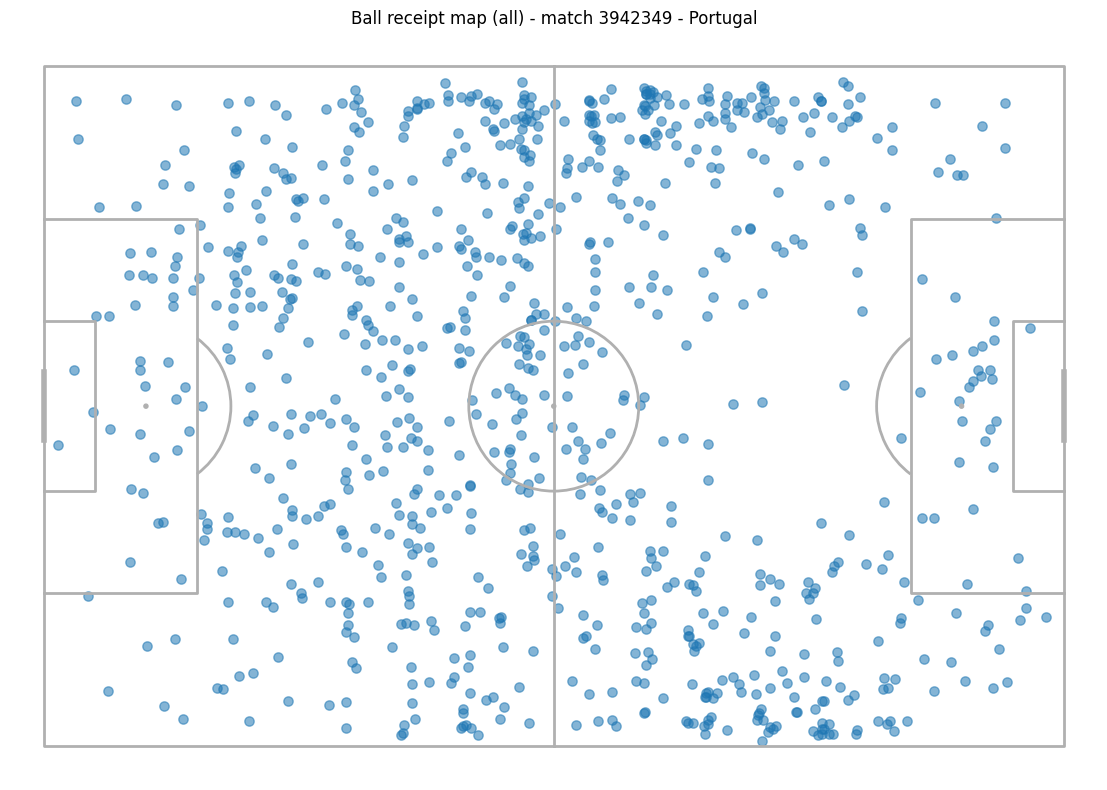

In [15]:
pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

# todas las recepciones
pitch.scatter(
    r_team["x"], r_team["y"],
    ax=ax,
    s=45,
    alpha=0.55,
)

ax.set_title(f"Ball receipt map (all) - match {match_id} - {team_name}")
plt.show()


7) Mapa de recepciones completadas vs incompletas

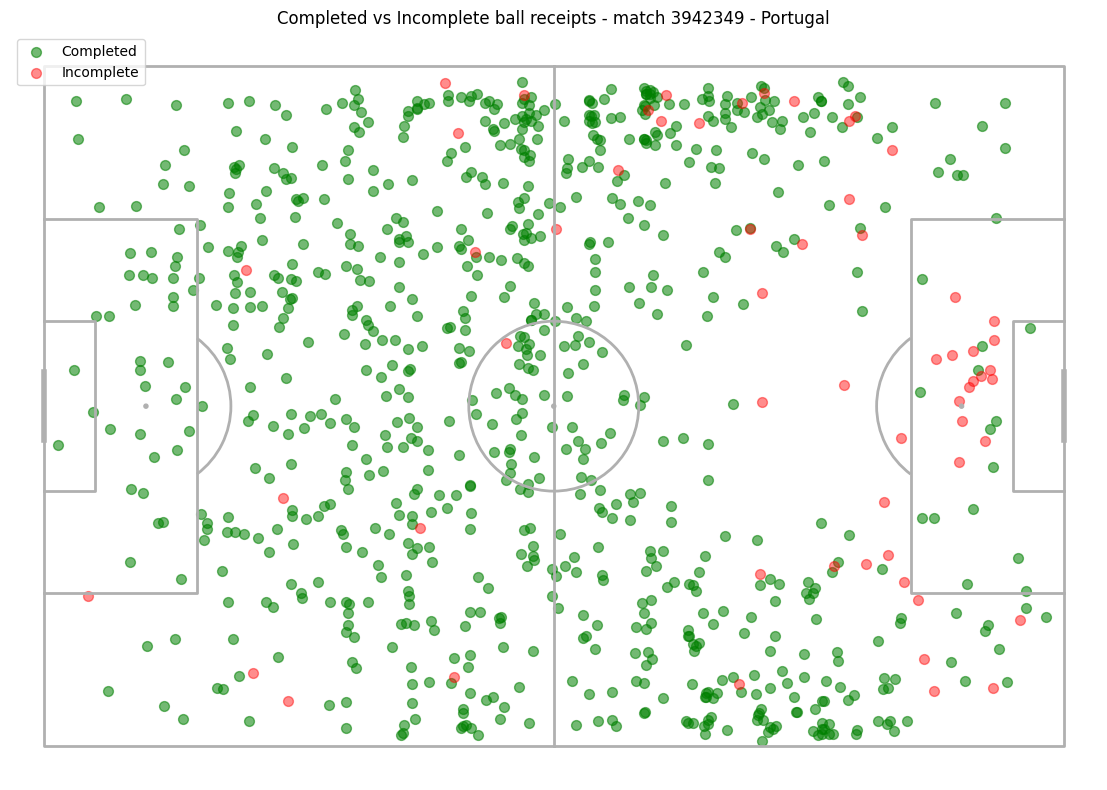

In [16]:
pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

completed = r_team[r_team["is_completed"]]
incomplete = r_team[~r_team["is_completed"]]

if not completed.empty:
    pitch.scatter(
        completed["x"], completed["y"],
        ax=ax,
        s=50,
        color="green",
        alpha=0.55,
        label="Completed",
    )

if not incomplete.empty:
    pitch.scatter(
        incomplete["x"], incomplete["y"],
        ax=ax,
        s=50,
        color="red",
        alpha=0.45,
        label="Incomplete",
    )

ax.set_title(f"Completed vs Incomplete ball receipts - match {match_id} - {team_name}")
ax.legend(loc="upper left")
plt.show()


8) Mapa de recepciones de un jugador

In [17]:
r_team["player"].value_counts().head(10)


player
Kléper Laveran Lima Ferreira                132
Rúben Santos Gato Alves Dias                103
Vitor Machado Ferreira                       99
Nuno Mendes                                  97
Bernardo Mota Veiga de Carvalho e Silva      87
João Maria Lobo Alves Palhinha Gonçalves     64
Rafael Alexandre Conceição Leão              53
Bruno Miguel Borges Fernandes                48
Cristiano Ronaldo dos Santos Aveiro          44
João Pedro Cavaco Cancelo                    43
Name: count, dtype: int64

In [18]:
player_name = r_team["player"].value_counts().index[0]
player_name


'Kléper Laveran Lima Ferreira'

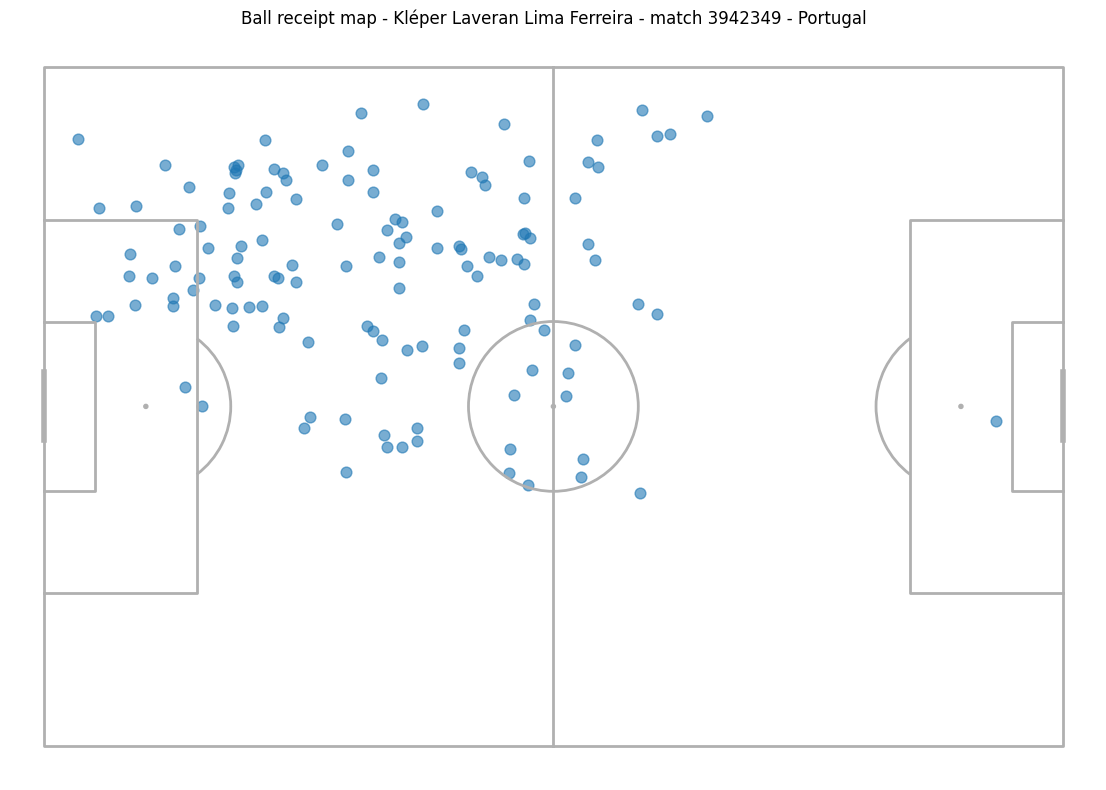

In [19]:
r_player = r_team[r_team["player"] == player_name].copy()

pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

pitch.scatter(
    r_player["x"], r_player["y"],
    ax=ax,
    s=60,
    alpha=0.6,
)

ax.set_title(f"Ball receipt map - {player_name} - match {match_id} - {team_name}")
plt.show()


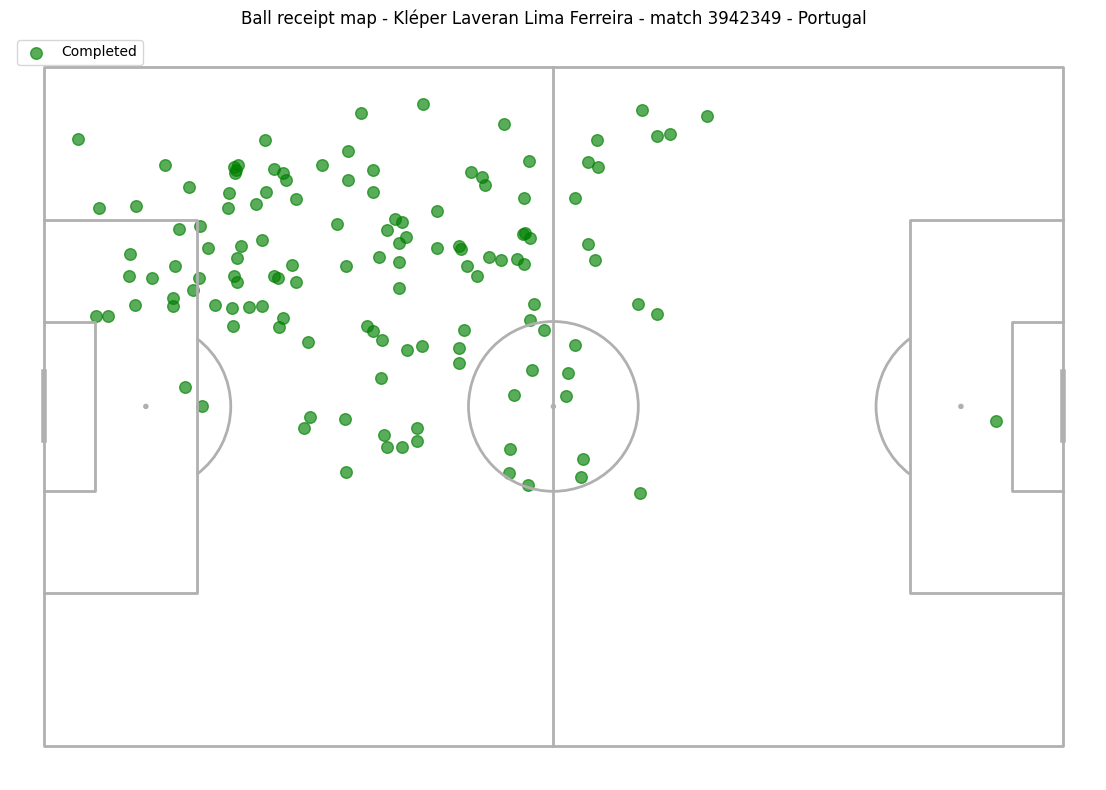

In [20]:
# filtrar recepciones del jugador
r_player = r_team[r_team["player"] == player_name].copy()

completed = r_player[r_player["is_completed"]]
incomplete = r_player[~r_player["is_completed"]]

pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

# recepciones completadas (verde)
if not completed.empty:
    pitch.scatter(
        completed["x"], completed["y"],
        ax=ax,
        s=70,
        color="green",
        alpha=0.65,
        label="Completed",
    )

# recepciones incompletas (rojo)
if not incomplete.empty:
    pitch.scatter(
        incomplete["x"], incomplete["y"],
        ax=ax,
        s=70,
        color="red",
        alpha=0.5,
        label="Incomplete",
    )

ax.set_title(f"Ball receipt map - {player_name} - match {match_id} - {team_name}")
ax.legend(loc="upper left")

plt.show()


In [21]:
# si tu dataset tiene pass_length (lo tiene tu script)
r_team["source_pass_length"].describe()


count    897.000000
mean      18.630197
std       11.100308
min        1.200000
25%       11.001818
50%       16.022797
75%       22.768398
max       89.303360
Name: source_pass_length, dtype: float64

9) Filtrado de recepciones: recepciones tras pases largos

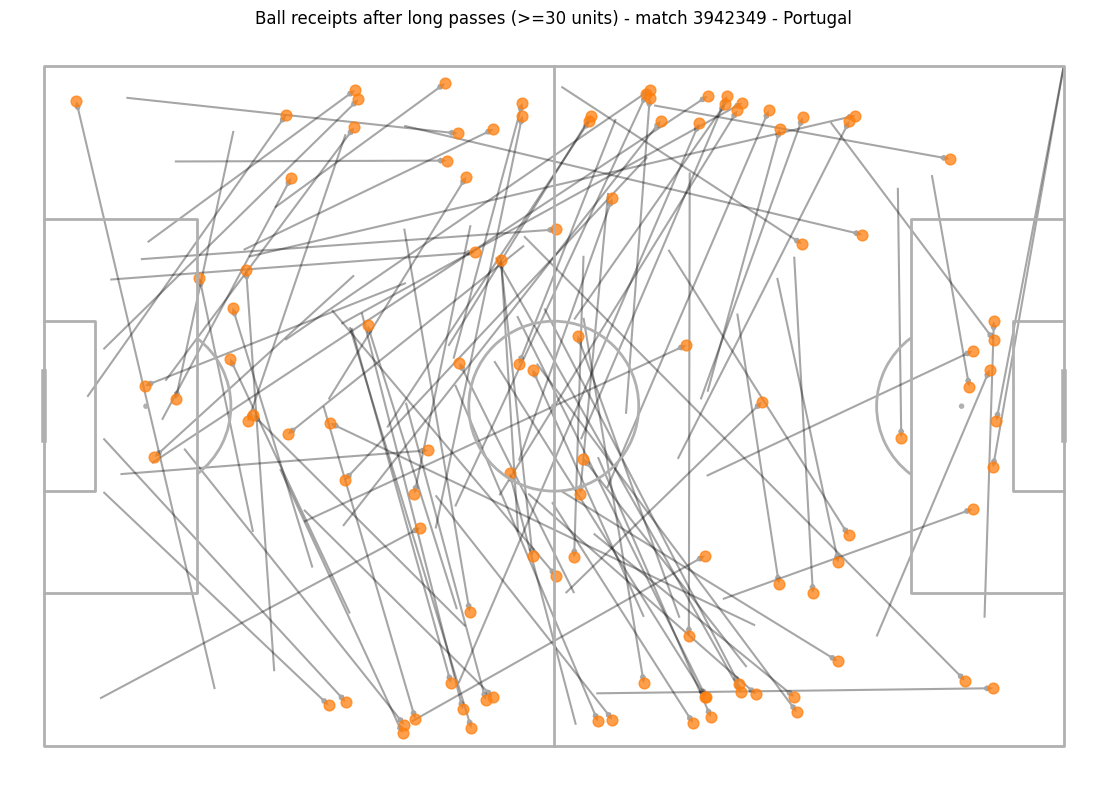

In [22]:
long_receipts = r_team[r_team["source_pass_length"] >= 30].copy()

pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

pitch.arrows(
    long_receipts["source_pass_x"], long_receipts["source_pass_y"],
    long_receipts["x"], long_receipts["y"],
    ax=ax,
    width=1.5,
    headwidth=3,
    headlength=3,
    alpha=0.35,
)

pitch.scatter(
    long_receipts["x"], long_receipts["y"],
    ax=ax,
    s=60,
    color="tab:orange",
    alpha=0.75,
)

ax.set_title(f"Ball receipts after long passes (>=30 units) - match {match_id} - {team_name}")
plt.show()
